# 📥 **1. Data Loading & Initial Inspection**

Data Loading: This step imports your CSV file into the notebook to make the dataset accessible for the project.

Initial Inspection: It checks the basic structure of the data by displaying the total rows, columns, and the first few records.


In [1]:
import pandas as pd

# Replace with your actual file name if it is different
file_name = "prediction_data.csv"  

try:
    df = pd.read_csv(file_name)
    print("====================================")
    print("Success! Dataset loaded into 'df'.")
    print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
    print("====================================")
except FileNotFoundError:
    print(f"Error: '{file_name}' not found. Please make sure this notebook and your CSV file are in the exact same folder.")

Success! Dataset loaded into 'df'.
Total Rows: 6418 | Total Columns: 32


# ⚙️ **2. Data Preprocessing, Feature Encoding & Splitting**

Data Cleaning & Encoding: This step automatically handles missing values, cleans up mixed data types, and converts text features into numerical formats that the model can understand.

Data Splitting: It splits the dataset into training and testing sets ($X_{train}, X_{test}, y_{train}, y_{test}$) to ensure the model can be evaluated fairly on unseen data.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Automatically detect the target column
possible_targets = [col for col in df.columns if 'churn' isn col.lower()]
if not possible_targets:
    raise ValueError("Could not find a churn column in your dataset.")
target_col = possible_targets[0]

# 2. Drop unique identifier columns if they exist
df_cleaned = df.copy()
if 'Customer_ID' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['Customer_ID'])

# 3. Handle mixed/numeric data types and fill missing values for features
for col in df_cleaned.columns:
    if col == target_col:
        continue
    
    converted = pd.to_numeric(df_cleaned[col], errors='coerce')
    if converted.notna().sum() > (len(df_cleaned) / 2):
        df_cleaned[col] = converted
        median_val = np.nanmedian(df_cleaned[col].values)
        df_cleaned[col] = df_cleaned[col].fillna(0 if np.isnan(median_val) else median_val)
    else:
        df_cleaned[col] = df_cleaned[col].astype(str)
        mode_val = df_cleaned[col].mode()
        fill_val = mode_val[0] if not mode_val.empty else "Unknown"
        df_cleaned[col] = df_cleaned[col].fillna(fill_val)

# 4. Strict Encoding for features
for col in df_cleaned.columns:
    if col != target_col:
        if df_cleaned[col].dtype == 'object' or df_cleaned[col].dtype.name == 'string' or isinstance(df_cleaned[col].iloc[0], str):
            le = LabelEncoder()
            df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# 5. Fix Mixed Types in Target: Convert target to string first, then encode
df_cleaned[target_col] = df_cleaned[target_col].astype(str)
le_target = LabelEncoder()
df_cleaned[target_col] = le_target.fit_transform(df_cleaned[target_col])

# 6. Safety check for NaNs
df_cleaned = df_cleaned.fillna(0)

# 7. Split features and target
X = df_cleaned.drop(columns=[target_col])
y = df_cleaned[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("====================================")
print("Preprocessing & Splitting Complete!")
print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")
print(f"Any missing values left?: {X_train.isna().sum().sum()}")
print("====================================")

Preprocessing & Splitting Complete!
X_train Shape: (5134, 30) | X_test Shape: (1284, 30)
Any missing values left?: 0


# 🤖 **3. Model Training & Metrics Evaluation**

Model Training: This step initializes the Random Forest Classifier and trains it using the preprocessed training dataset so the model can learn customer behavior patterns.

Metrics Evaluation: It evaluates the model's predictive power on the test data by calculating the overall accuracy score, generating a detailed classification report, and identifying the top drivers of customer behavior.

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)

print("====================================")
print(f"  MODEL ACCURACY SCORE: {accuracy:.4f}")
print("====================================\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Extract and display Top 5 Most Important Features
importances = model.feature_importances_
feature_summary = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Drivers of Customer Behavior ---")
print(feature_summary.head(5).to_string(index=False))

  MODEL ACCURACY SCORE: 0.9712

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       0.99      1.00      0.99       132
           2       0.70      0.82      0.76        61
           3       0.93      0.83      0.88        30
           4       0.54      0.40      0.46        35
           5       1.00      1.00      1.00       965

    accuracy                           0.97      1284
   macro avg       0.86      0.84      0.85      1284
weighted avg       0.97      0.97      0.97      1284


--- Top 5 Drivers of Customer Behavior ---
        Feature  Importance
   Churn_Reason    0.345890
Customer_Status    0.334835
 Monthly_Charge    0.032626
  Total_Revenue    0.031222
  Total_Charges    0.029332


# 📊 **4. Model Visualizations & Performance Insights**

Visual Performance Analysis: This step creates a confusion matrix heatmap to visually break down the model's correct predictions versus its errors.

Feature Importance Insights: It plots a bar chart of the top driving features, making it easy to see exactly which factors have the biggest impact on customer behavior.

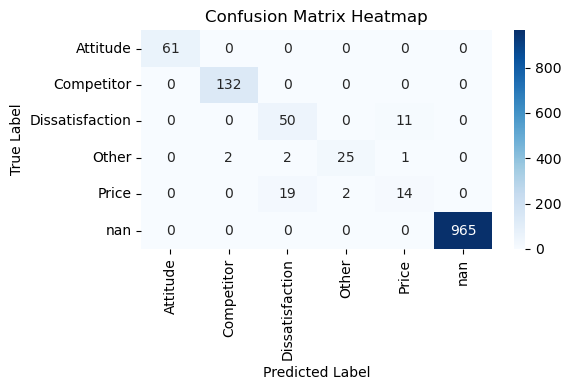

C:\Users\Afifah Khatoon\AppData\Local\Temp\ipykernel_6200\4246567138.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_summary.head(10), palette='viridis')


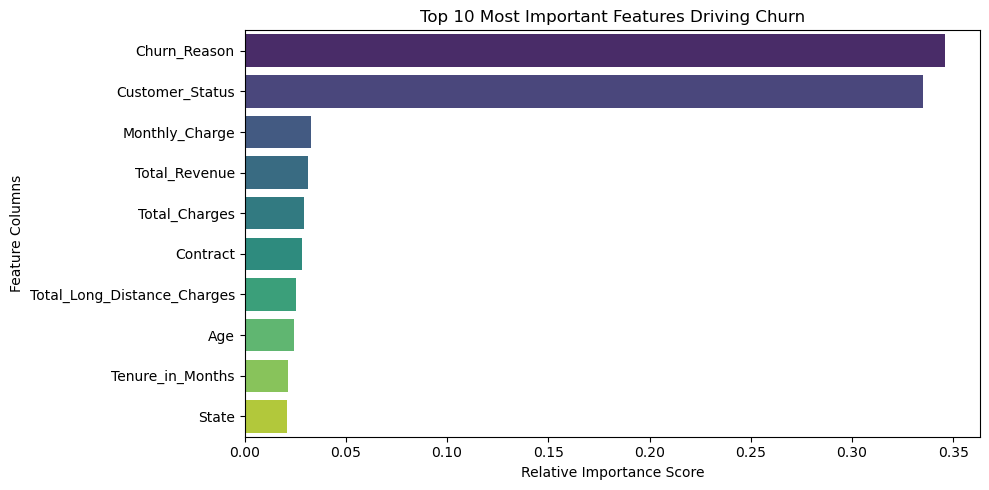

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate and plot the Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 2. Extract and plot the Top 10 Feature Importances
importances = model.feature_importances_
feature_summary = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_summary.head(10), palette='viridis')
plt.title('Top 10 Most Important Features Driving Churn')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Columns')
plt.tight_layout()
plt.show()

# 🔮 **5. Predicting the Future (Scoring New Data)**

Future Deployment: This step simulates how the trained model operates in production by taking brand new, unseen customer profiles and forecasting their next move.

Risk Probability Scoring: It calculates a specific percentage probability score for each customer, allowing companies to proactively target high-risk users with retention offers before they leave.

In [5]:
import pandas as pd

# 1. Simulate brand new customers who haven't churned yet (Future Data)
# We take a small sample from your existing X_test structure just to demonstrate
new_customers = X_test.head(3).copy()

# 2. Let the trained model predict the future behavior of these new customers
future_predictions = model.predict(new_customers)
future_probabilities = model.predict_proba(new_customers)[:, 1] # Probability of churning

# 3. Decode the numerical predictions back to original labels (e.g., 'Yes' or 'No')
decoded_predictions = le_target.inverse_transform(future_predictions)

# 4. Display the Actionable Insights for the Business Team
prediction_results = pd.DataFrame({
    'Customer_Row_Index': new_customers.index,
    'Will_They_Churn?': decoded_predictions,
    'Churn_Probability_Score': [f"{prob*100:.1f}%" for prob in future_probabilities]
})

print("==================================================")
print("🔮 FUTURE CHURN PREDICTIONS FOR NEW CUSTOMERS 🔮")
print("==================================================")
print(prediction_results.to_string(index=False))
print("==================================================")

🔮 FUTURE CHURN PREDICTIONS FOR NEW CUSTOMERS 🔮
 Customer_Row_Index Will_They_Churn? Churn_Probability_Score
               3559              NaN                    5.0%
               3426              NaN                    0.0%
               5783              NaN                    0.0%
